# Rede Neural do Zero - Do Básico ao Avançado 

Este notebook constrói uma rede neural ** usando apenas NumpY**, sem frameworks como PytTorch ou TensorFlow. 
O objetivo é entender exatamente o que acentece "por baixo do capô" quando uma rede neural aprende.

1. O neurônio artificial (perceptron)
2. Funções de ativação 
3. Por que um único neurônio não resolve tudo (o problema do XOR)
4. Rede neural com uma camada osulta (forward + backward do zero)
5. Uma rede neral genérica e configuravel (MLP)
6. Técnicas avançadas: mini-batch, momentum, regularização L2, inicialização de pesos
7. Capstone: reconhecimento de dígitos escritos à mão
8. Próximos passos (PyTorch e além)

> Pré-requisitos: Python intermediário e álgebra linear básica (vetores, matrizes). Não é preciso saber cálculo a fundo — as fórmulas de derivada já vêm prontas, com explicação do que representam.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
plt.rcParams['figure.figsize'] = (7, 4)

## 1. O neurônio artificial

Um neurônio artificial faz duas coisas 

1. Calcula uma soma ponderada das entradas: `z = w1*x1 + w2*x2 + ... + b`
2. Aplica uma **função de ativação**: `a = f(z)`

Isso é literalemente regressão linear seguida de uma não-linearidade. Vamos implementar isso manualmente. 

In [2]:
def neuronio(x, w, b):
  """Um neurônio: soma ponderada + ativação."""
  z = np.dot(x, w) + b
  a = 1 / (1 + np.exp(-z)) # sigmoid
  return a

# Exemplo: 3 entradas 
x = np.array([1.0, 0.5, -1.2])
w = np.array([0.4, -0.6, 0.3])
b = 0.1

sainda = neuronio(x, w, b)
print(f"Saída do neurônio: {sainda:.4f}")

Saída do neurônio: 0.4601


## 2. Funções de ativação

Sem uma função de ativação não-linear, empilhar camadas seria inútil — a composição de funções lineares
continua sendo linear. As mais usadas:

| Função | Fórmula | Uso comum |
|---|---|---|
| Sigmoide | `1/(1+e^-z)` | Saída binária (probabilidade) |
| Tanh | `(e^z - e^-z)/(e^z + e^-z)` | Camadas ocultas (antigo padrão) |
| ReLU | `max(0, z)` | Camadas ocultas (padrão atual) |
| Softmax | `e^zi / soma(e^zj)` | Saída multi-classe |

Vamos visualizar as três primeiras.

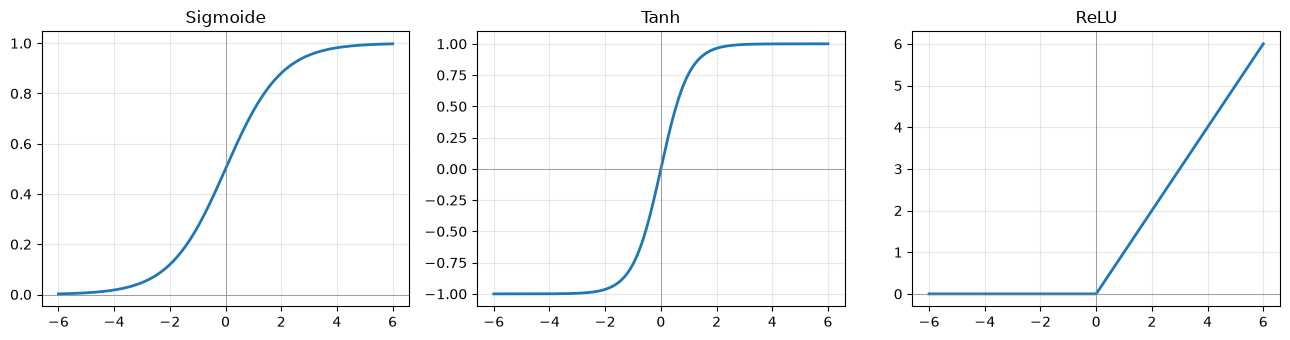

In [7]:
def sigmoid(z):
  return 1 / (1 + np.exp(-z))

def tanh(z):
  return np.tanh(z)

def relu(z):
  return np.maximum(0, z)

z = np.linspace(-6, 6, 200)

fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
for ax, (nome, fn) in zip(axes, [("Sigmoide", sigmoid), ("Tanh", tanh), ("ReLU", relu)]):
    ax.plot(z, fn(z), linewidth=2)
    ax.set_title(nome)
    ax.axhline(0, color='gray', linewidth=0.5)
    ax.axvline(0, color='gray', linewidth=0.5)
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()    

## 3. Treinamento um úniico neurônio (Perceptron)

Vamos treinar um neurônio para aprender a porta lógica **AND**, ajustando os pesos com grandiente descentes manual.

A regra de atualização é a simples:

`w = w - taxa_apredizado * gradiente`

Para um neurônio com ativação sigmoide e erro quadrático, o gradiante em relação a cada peso é:
`(saida - alvo) * saida * (1 - saida) * entrada`

Pesos finais: [5.49209662 5.4902854 ]
Bias final: -8.326088201048792

Entrada [0 0] -> previsto 0.000 (alvo 0)
Entrada [0 1] -> previsto 0.055 (alvo 0)
Entrada [1 0] -> previsto 0.056 (alvo 0)
Entrada [1 1] -> previsto 0.934 (alvo 1)


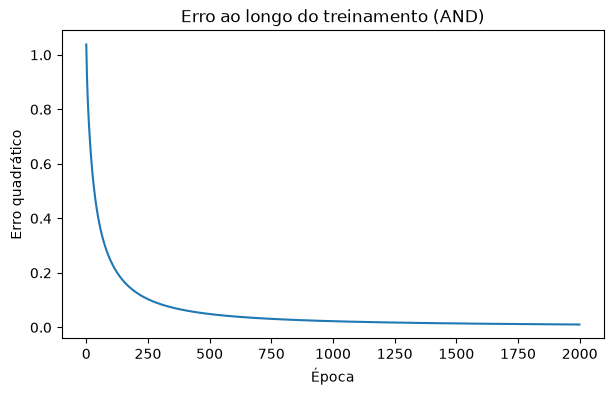

In [13]:
# Dataset da porta AND
X_and = np.array([[0,0],[0,1],[1,0],[1,1]])
y_and = np.array([0,0,0,1])

w = np.random.randn(2) * 0.1
b = 0.0
lr = 0.5

historico_erro = []

for epoca in range(2000):
    erro_total = 0
    for x, alvo in zip(X_and, y_and):
        z = np.dot(x, w) + b
        saida = sigmoid(z)
        erro = alvo - saida
        erro_total += erro**2

        # gradiente (regra delta)
        gradiente = erro * saida * (1 - saida)
        w += lr * gradiente * x
        b += lr * gradiente

    historico_erro.append(erro_total)

print("Pesos finais:", w)
print("Bias final:", b)
print()
for x, alvo in zip(X_and, y_and):
    pred = sigmoid(np.dot(x, w) + b)
    print(f"Entrada {x} -> previsto {pred:.3f} (alvo {alvo})")

plt.plot(historico_erro)
plt.title("Erro ao longo do treinamento (AND)")
plt.xlabel("Época")
plt.ylabel("Erro quadrático")
plt.show()


Funcionou bem para AND porque essa função é **linearmente separável** - dá para traçar uma reta separando as classes 0 e 1. Agora tenta o mesmo código com a porta **XOR**:

``
0 XOR 0 = 0
0 XOR 1 = 1
1 XOR 0 = 1
1 XOR 1 = 0
``

Rode a célula abaixo e observa o erro: ele não cai de vardade. Um único neurônio **não consegue** resolver XOR, porque não existe reta que separa as duas classes. É exatamente esse limite que motiva o uso de **camadas ocultas** - é daí que vem a ideia de "deep learning".

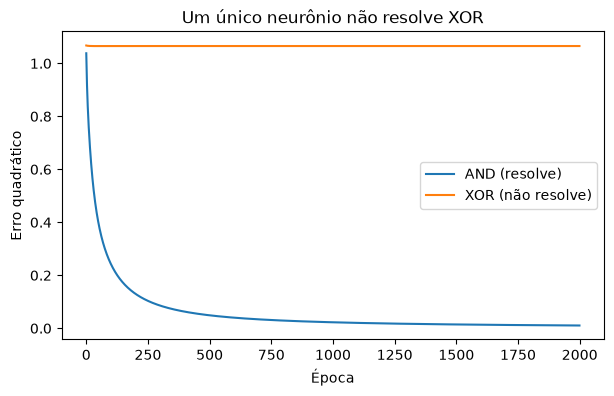

In [14]:
X_xor = np.array([[0,0],[0,1],[1,0],[1,1]])
y_xor = np.array([0,1,1,0])

w = np.random.randn(2) * 0.1
b = 0.0
historico_erro_xor = []

for epoca in range(2000):
    erro_total = 0
    for x, alvo in zip(X_xor, y_xor):
        z = np.dot(x, w) + b
        saida = sigmoid(z)
        erro = alvo - saida
        erro_total += erro**2
        gradiente = erro * saida * (1 - saida)
        w += lr * gradiente * x
        b += lr * gradiente
    historico_erro_xor.append(erro_total)

plt.plot(historico_erro, label="AND (resolve)")
plt.plot(historico_erro_xor, label="XOR (não resolve)")
plt.title("Um único neurônio não resolve XOR")
plt.xlabel("Época")
plt.ylabel("Erro quadrático")
plt.legend()
plt.show()
